# Reddit 评论合并清洗 / Combined Reddit Comment Cleaning

本 notebook 将原来的两轮清洗合并为一次完整流程：直接读取 `D:\DM1_project\reddit_opinion_climate_change.csv`，生成最终清洗数据、删除审计和清洗报告。不会覆盖原始 CSV。 / This notebook combines both cleaning passes into one workflow. It reads the original CSV, writes the final cleaned dataset, removal audit, and cleaning report, and never overwrites the source file.

## 清洗原则 / Cleaning Principles

**删除：** 空文本、明确删除占位符、明确版规/删除通知、审核机器人模板、URL 清除后变为空的文本、重复评论 ID。

**保留：** 负分或低分评论、争议评论、真实短回复、普通重复回复、缺少帖子正文、缺少 karma，以及普通用户讨论删除行为的内容。

Removed: blank text, deletion placeholders, explicit moderation/removal notices, recognized moderation-bot templates, URL-only text, and duplicate comment IDs. Retained: negative/low-score comments, controversial comments, genuine short or repeated replies, missing post body/karma, and ordinary discussion about moderation.

## 清洗逻辑概述 / Cleaning Logic Summary

1. **读取数据 / Load data**：读取原始 Reddit CSV，并保留原始字段；不覆盖源文件。 / Load the raw Reddit CSV, preserve all original fields, and never overwrite the source file.
2. **第一阶段删除 / Stage 1 removal**：删除空评论、删除占位符、明确的删除通知、自动审核机器人模板，以及重复的 `comment_id`；每行只记录第一个命中原因。 / Remove blank comments, deletion placeholders, explicit removal notices, recognized automated-moderation templates, and duplicate `comment_id` values; record the first matching reason for each row.
3. **文本规范化 / Text normalization**：保留原始 `self_text`，同时生成 `clean_text`；解码 HTML、保留 Markdown 链接文字、删除 URL、合并多余空白。 / Preserve `self_text` and create `clean_text`; decode HTML, keep visible Markdown-link text, remove URLs, and collapse extra whitespace.
4. **第二阶段删除 / Stage 2 removal**：删除规范化后仍为空的文本、残留占位符、结构明确的评论/帖子删除通知，以及来自已识别审核账户的删除模板；普通讨论删除行为的评论保留。 / Remove text that is empty after normalization, residual placeholders, clearly structured comment/post removal notices, and removal templates from recognized moderation accounts; retain ordinary discussions about moderation.
5. **生成数据与审计 / Build data and audit**：保留清洗后的评论，增加文本长度、词数、帖子正文可用性、用户 metadata 可用性和时间字段；被删除记录保留完整原字段、清洗阶段及删除原因。 / Keep cleaned comments and add text length, word count, post-text availability, user-metadata availability, and parsed datetime fields; retain full original fields plus removal stage and reason for deleted rows.
6. **验证与输出 / Validate and export**：检查重复 ID、空文本、删除占位符、审核模板及关键分数列一致性；输出最终清洗数据、删除审计文件和规则报告。 / Check duplicate IDs, blank text, deletion placeholders, moderation templates, and key score-column consistency; export the final cleaned data, removal audit, and rule report.

**保留原则 / Retention principle**：不因低分、争议、短回复、普通重复回复、缺少帖子正文或缺少 karma 而删除。 / Do not remove comments solely because they have low scores, are controversial, are short or repeated, or lack post text or karma.

## 1. 设置路径与读取原始文件 / Set Paths and Load the Raw File

In [1]:
import html
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_DIR = Path(r"D:\DM1_project")
RAW_DATA_PATH = PROJECT_DIR / "reddit_opinion_climate_change.csv"
FINAL_DATA_PATH = PROJECT_DIR / "reddit_opinion_climate_change_cleaned_final.csv.gz"
REMOVAL_AUDIT_PATH = PROJECT_DIR / "reddit_cleaning_removed_audit.csv.gz"
CLEANING_REPORT_PATH = PROJECT_DIR / "reddit_cleaning_report_final.csv"

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["figure.dpi"] = 120

df = pd.read_csv(RAW_DATA_PATH, low_memory=False)

print("Source:", RAW_DATA_PATH)
print("Original shape:", df.shape)
print("Unique comment IDs:", f"{df['comment_id'].nunique():,}")

Source: D:\DM1_project\reddit_opinion_climate_change.csv
Original shape: (1903836, 24)
Unique comment IDs: 1,903,836


预期读取 1,903,836 行、24 列。文件较大，读取时间取决于硬盘速度和内存。 / Expected input: 1,903,836 rows and 24 columns. Loading time depends on disk speed and memory.

## 2. 第一阶段：原始文本规则 / Stage 1: Raw-Text Rules

In [ ]:
raw_text = df["self_text"].astype("string")
stripped_text = raw_text.str.strip()
lower_text = stripped_text.str.lower()

stage1_masks = {
    "missing_or_blank_comment_text": raw_text.isna() | stripped_text.eq(""),
    "deletion_placeholder": lower_text.isin({
        "[deleted]", "[removed]", "[removed by reddit]", "deleted", "removed"
    }).fillna(False),
    "initial_removal_notice": lower_text.str.contains(
        r"^(?:your |this )?(?:comment|post)\s+(?:has been|was|is)\s+removed\b"
        r"|^comment\s+removed\s+by\s+(?:moderator|reddit)\b"
        r"|^removed\s+for\s+(?:breaking|violating)\b",
        regex=True, na=False
    ),
    "automatic_removal_footer": (
        lower_text.str.contains(
            r"i am a bot, and this action was performed automatically", regex=True, na=False
        )
        & lower_text.str.contains(r"remov|rule|moderator", regex=True, na=False)
    ),
    "duplicate_comment_id": df["comment_id"].duplicated(keep="first"),
}

stage1_remove = pd.Series(False, index=df.index)
stage1_reason = pd.Series("", index=df.index, dtype="object")
for reason, mask in stage1_masks.items():
    new_matches = mask & ~stage1_remove
    stage1_reason.loc[new_matches] = reason
    stage1_remove |= mask

stage1_counts = pd.DataFrame({
    "stage": "stage_1_raw_text",
    "rule": list(stage1_masks),
    "raw_matches": [int(mask.sum()) for mask in stage1_masks.values()],
    "exclusive_removed": [int(stage1_reason.eq(reason).sum()) for reason in stage1_masks],
})
stage1_counts

,stage,rule,raw_matches,exclusive_removed
0,stage_1_raw_text,missing_or_blank_comment_text,16,16
1,stage_1_raw_text,deletion_placeholder,1,1
2,stage_1_raw_text,initial_removal_notice,2633,2633
3,stage_1_raw_text,automatic_removal_footer,37,37
4,stage_1_raw_text,duplicate_comment_id,0,0


同一条记录可能符合多个规则，因此报告同时显示原始命中数和互斥删除数。 / A row may match multiple rules, so both raw matches and mutually exclusive removal counts are reported.

## 3. 保留原文并创建 clean_text / Preserve Raw Text and Create clean_text

In [3]:
def normalize_comment_text(value):
    value = html.unescape(str(value))
    value = re.sub(r"\[([^\]]+)\]\(https?://[^)]+\)", r"\1", value)
    value = re.sub(r"https?://\S+|www\.\S+", " ", value)
    value = re.sub(r"\s+", " ", value)
    return value.strip()

working = df.loc[~stage1_remove].copy()
working["clean_text"] = working["self_text"].map(normalize_comment_text)

empty_after_normalization = working["clean_text"].eq("")
print("Rows entering normalization:", f"{len(working):,}")
print("Rows empty after URL/whitespace normalization:", f"{empty_after_normalization.sum():,}")

Rows entering normalization: 1,901,149
Rows empty after URL/whitespace normalization: 5,132


原始 `self_text` 始终保留；`clean_text` 删除 URL 和多余空白，但保留 Markdown 链接中可见的文字。 / Original `self_text` is retained. `clean_text` removes URLs and excess whitespace while preserving visible Markdown link text.

## 4. 第二阶段：长审核模板与残留空文本 / Stage 2: Long Moderation Templates and Residual Empty Text

In [4]:
text = working["clean_text"].fillna("").astype(str).str.strip()
text_lower = text.str.lower()
author_lower = working["author_name"].fillna("").astype(str).str.lower()

explicit_comment_phrase = text_lower.str.contains(
    r"\b(?:your|this|the)\s+comments?(?:\s+here\s+and\s+below)?\s+(?:has|have)\s+been\s+removed\b",
    regex=True, na=False
)
notice_structure = (
    text_lower.str.match(
        r"^\s*(?:sorry[,!]?\s*)?(?:u/[^\s,]+.*?\s+)?(?:your|this|the)\s+comments?",
        na=False
    )
    | text_lower.str.contains(r"\bbreaking\s+rule\s*[0-9a-z]?\b", regex=True, na=False)
    | text_lower.str.contains(
        r"\bappeal(?:s|ing)?\b.{0,100}\b(?:moderator|removal|removed)\b",
        regex=True, na=False
    )
)

moderation_author = author_lower.str.contains(
    r"automoderator|modteam|read-the-rules|ukbot|revddit", regex=True, na=False
)

stage2_masks = {
    "empty_after_normalization": empty_after_normalization,
    "residual_deletion_placeholder": (
        text_lower.isin(["[deleted]", "[removed]", "deleted", "removed"])
        | text.isin(["None", "NaN", "<NA>"])
    ),
    "explicit_comment_removal_notice": explicit_comment_phrase & notice_structure,
    "explicit_post_removal_notice": text_lower.str.contains(
        r"^\s*(?:sorry[,!]?\s*)?(?:u/[^\s,]+.*?\s+)?your\s+post\s+has\s+been\s+removed\s+for\s+breaking\s+rule",
        regex=True, na=False
    ),
    "recognized_moderation_template": moderation_author & text_lower.str.contains(
        r"removed|breaking\s+rule|reviewing\s+removed\s+content", regex=True, na=False
    ),
}

stage2_remove = pd.Series(False, index=working.index)
stage2_reason = pd.Series("", index=working.index, dtype="object")
for reason, mask in stage2_masks.items():
    new_matches = mask & ~stage2_remove
    stage2_reason.loc[new_matches] = reason
    stage2_remove |= mask

stage2_counts = pd.DataFrame({
    "stage": "stage_2_normalized_text",
    "rule": list(stage2_masks),
    "raw_matches": [int(mask.sum()) for mask in stage2_masks.values()],
    "exclusive_removed": [int(stage2_reason.eq(reason).sum()) for reason in stage2_masks],
})
stage2_counts

,stage,rule,raw_matches,exclusive_removed
0,stage_2_normalized_text,empty_after_normalization,5132,5132
1,stage_2_normalized_text,residual_deletion_placeholder,1,1
2,stage_2_normalized_text,explicit_comment_removal_notice,663,663
3,stage_2_normalized_text,explicit_post_removal_notice,28,28
4,stage_2_normalized_text,recognized_moderation_template,959,449


规则要求明确模板结构或已识别审核账户，以避免误删普通用户正常讨论“内容被删除”的评论。 / Rules require explicit template structure or recognized moderation accounts, reducing false removal of ordinary discussion about moderation.

## 5. 建立最终数据与删除审计 / Build Final Data and Removal Audit

In [5]:
df_clean = working.loc[~stage2_remove].copy()

df_clean["comment_char_count"] = df_clean["clean_text"].str.len()
df_clean["comment_word_count"] = df_clean["clean_text"].str.split().str.len()
df_clean["has_post_self_text"] = df_clean["post_self_text"].notna()

karma_columns = [
    "user_awardee_karma", "user_awarder_karma", "user_link_karma",
    "user_comment_karma", "user_total_karma"
]
df_clean["user_metadata_available"] = df_clean[karma_columns].notna().all(axis=1)

for column in ["created_time", "post_created_time", "user_account_created_time"]:
    df_clean[column] = pd.to_datetime(df_clean[column], errors="coerce")

removed_stage1 = df.loc[stage1_remove].copy()
removed_stage1["clean_text"] = removed_stage1["self_text"].fillna("").map(normalize_comment_text)
removed_stage1["removal_stage"] = "stage_1_raw_text"
removed_stage1["removal_reason"] = stage1_reason.loc[stage1_remove].values

removed_stage2 = working.loc[stage2_remove].copy()
removed_stage2["removal_stage"] = "stage_2_normalized_text"
removed_stage2["removal_reason"] = stage2_reason.loc[stage2_remove].values

audit_columns = list(df.columns) + ["clean_text", "removal_stage", "removal_reason"]
removed_audit = pd.concat(
    [removed_stage1[audit_columns], removed_stage2[audit_columns]],
    ignore_index=True
)

summary = pd.DataFrame({
    "metric": [
        "Original rows", "Stage 1 removed", "Stage 2 removed",
        "Total removed", "Final rows", "Overall retention rate"
    ],
    "value": [
        len(df), int(stage1_remove.sum()), int(stage2_remove.sum()),
        len(removed_audit), len(df_clean), len(df_clean)/len(df)
    ]
})
summary

,metric,value
0,Original rows,1.903836e+06
1,Stage 1 removed,2.687000e+03
2,Stage 2 removed,6.273000e+03
3,Total removed,8.960000e+03
4,Final rows,1.894876e+06
5,Overall retention rate,9.952937e-01


删除审计保留原始 24 个字段、规范化文本、清洗阶段和删除原因，可以逐条复核或恢复。 / The audit retains all original fields, normalized text, cleaning stage, and removal reason for row-level review or recovery.

## 6. 规则影响与社区分布 / Rule Impact and Subreddit Distribution

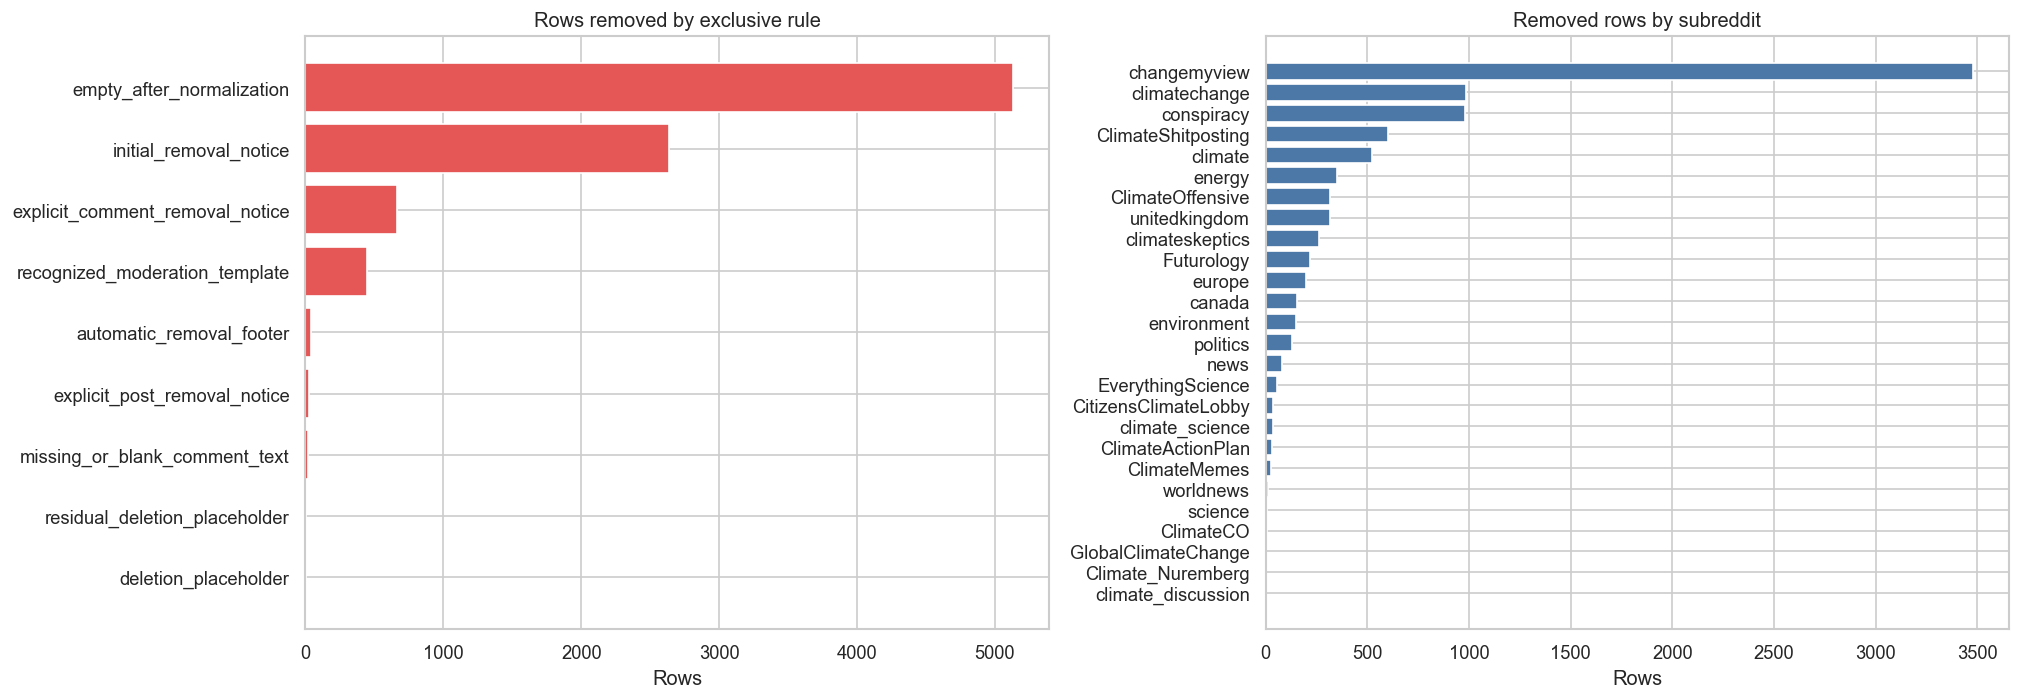

,stage,rule,raw_matches,exclusive_removed
0,stage_1_raw_text,missing_or_blank_comment_text,16,16
1,stage_1_raw_text,deletion_placeholder,1,1
2,stage_1_raw_text,initial_removal_notice,2633,2633
3,stage_1_raw_text,automatic_removal_footer,37,37
4,stage_1_raw_text,duplicate_comment_id,0,0
5,stage_2_normalized_text,empty_after_normalization,5132,5132
6,stage_2_normalized_text,residual_deletion_placeholder,1,1
7,stage_2_normalized_text,explicit_comment_removal_notice,663,663
8,stage_2_normalized_text,explicit_post_removal_notice,28,28
9,stage_2_normalized_text,recognized_moderation_template,959,449


,before,removed,after,removed_share
subreddit,,,,
changemyview,190694,3480,187214,0.018249
climatechange,246907,983,245924,0.003981
conspiracy,244513,982,243531,0.004016
ClimateShitposting,52827,600,52227,0.011358
climate,179549,522,179027,0.002907
energy,121263,350,120913,0.002886
ClimateOffensive,21113,317,20796,0.015014
unitedkingdom,61373,316,61057,0.005149
climateskeptics,73304,262,73042,0.003574


In [6]:
rule_report = pd.concat([stage1_counts, stage2_counts], ignore_index=True)
impact = pd.DataFrame({
    "before": df["subreddit"].value_counts(),
    "removed": removed_audit["subreddit"].value_counts(),
    "after": df_clean["subreddit"].value_counts(),
}).fillna(0).astype(int)
impact["removed_share"] = impact["removed"] / impact["before"]
impact = impact.sort_values("removed", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
rule_plot = rule_report.loc[rule_report["exclusive_removed"].gt(0)].sort_values("exclusive_removed")
axes[0].barh(rule_plot["rule"], rule_plot["exclusive_removed"], color="#E45756")
axes[0].set_title("Rows removed by exclusive rule")
axes[0].set_xlabel("Rows")

community_plot = impact.loc[impact["removed"].gt(0)].sort_values("removed")
axes[1].barh(community_plot.index, community_plot["removed"], color="#4C78A8")
axes[1].set_title("Removed rows by subreddit")
axes[1].set_xlabel("Rows")
plt.tight_layout()
plt.show()

display(rule_report)
impact

社区受影响比例用于发现规则是否异常集中。审核通知集中于具有明显 ModTeam 模板的社区是预期现象。 / Community impact helps detect abnormal rule behavior. Concentration in communities with explicit ModTeam templates is expected.

## 7. 最终验证 / Final Validation

In [7]:
final_text = df_clean["clean_text"].fillna("").astype(str).str.strip()
final_lower = final_text.str.lower()
final_author = df_clean["author_name"].fillna("").astype(str).str.lower()

final_mod_author = final_author.str.contains(
    r"automoderator|modteam|read-the-rules|ukbot|revddit", regex=True, na=False
)
final_mod_template = final_mod_author & final_lower.str.contains(
    r"removed|breaking\s+rule|reviewing\s+removed\s+content", regex=True, na=False
)

validation = pd.DataFrame({
    "check": [
        "Final rows", "Final columns", "Duplicate comment IDs", "Missing clean_text",
        "Blank clean_text", "Deletion placeholders", "Target moderation templates",
        "score equals ups", "post_score equals post_thumbs_ups"
    ],
    "result": [
        len(df_clean), df_clean.shape[1], int(df_clean["comment_id"].duplicated().sum()),
        int(df_clean["clean_text"].isna().sum()), int(final_text.eq("").sum()),
        int((
            final_lower.isin(["[deleted]", "[removed]", "deleted", "removed"])
            | final_text.isin(["None", "NaN", "<NA>"])
        ).sum()),
        int(final_mod_template.sum()), bool(df_clean["score"].equals(df_clean["ups"])),
        bool(df_clean["post_score"].equals(df_clean["post_thumbs_ups"]))
    ]
})
validation

,check,result
0,Final rows,1894876
1,Final columns,29
2,Duplicate comment IDs,0
3,Missing clean_text,0
4,Blank clean_text,0
5,Deletion placeholders,0
6,Target moderation templates,0
7,score equals ups,True
8,post_score equals post_thumbs_ups,True


预期最终结果为 1,894,876 行、29 列；重复 ID、空文本、删除占位符和目标审核模板均为 0。 / Expected final output: 1,894,876 rows and 29 columns, with zero duplicate IDs, blank text, deletion placeholders, or targeted moderation templates.

## 8. 保存最终数据、审计和报告 / Save Final Data, Audit, and Report

In [8]:
PROJECT_DIR.mkdir(parents=True, exist_ok=True)

df_clean.to_csv(
    FINAL_DATA_PATH, index=False, encoding="utf-8",
    compression={"method": "gzip", "compresslevel": 1}
)
removed_audit.to_csv(
    REMOVAL_AUDIT_PATH, index=False, encoding="utf-8",
    compression={"method": "gzip", "compresslevel": 1}
)
rule_report.to_csv(CLEANING_REPORT_PATH, index=False, encoding="utf-8-sig")

saved = pd.DataFrame({
    "file": ["Final cleaned data", "Removal audit", "Cleaning report"],
    "path": [FINAL_DATA_PATH, REMOVAL_AUDIT_PATH, CLEANING_REPORT_PATH],
    "rows": [len(df_clean), len(removed_audit), len(rule_report)],
    "size_mb": [
        FINAL_DATA_PATH.stat().st_size/1024**2,
        REMOVAL_AUDIT_PATH.stat().st_size/1024**2,
        CLEANING_REPORT_PATH.stat().st_size/1024**2,
    ]
})
saved

,file,path,rows,size_mb
0,Final cleaned data,D:\DM1_project\reddit_opinion_climate_change_c...,1894876,696.826859
1,Removal audit,D:\DM1_project\reddit_cleaning_removed_audit.c...,8960,5.057359
2,Cleaning report,D:\DM1_project\reddit_cleaning_report_final.csv,10,0.000566


1. 删除空评论 / Remove blank comments
2. 删除删除占位符 / Remove deletion placeholders
3. 删除明确的删除通知 / Remove explicit removal notices
Your comment has been removed
This post was removed
Comment removed by moderator
Removed for breaking rule
4. 删除自动审核模板 / Remove automated-moderation templates
5. 删除重复评论 ID / Remove duplicate comment IDs
6. 规范化文本 / Normalize the text
解码 HTML 实体 / Decode HTML entities
将 Markdown 链接 [文字](URL) 替换为可见文字 / Replace Markdown links with visible text
删除普通 URL / Remove ordinary URLs
合并连续空格 / Collapse repeated whitespace
删除首尾空格 / Strip leading and trailing spaces
8. 删除残留占位符 / Remove residual placeholders
9. 删除评论或帖子删除模板 / Remove comment or post-removal templates
通常要求文本同时具有删除通知结构，以及 breaking rule、appeal 或 moderator 等特征。
The text generally needs both a removal-notice structure and features such as breaking rule, appeal, or moderator.
Your comment has been removed
Your post has been removed for breaking rule 3
10. 删除已识别审核账户发布的模板 / Remove templates from recognized moderation accounts
先识别可能的审核账户：

First identify recognized moderation accounts:


然后要求其文本同时包含：

Their text must also contain:


也就是说，只有“审核账户 + 明确删除模板”同时满足时才删除。
A row is removed only when both a recognized moderation account and a clear removal template are present.